# Sentinel-2 → Crop CSV (preprocess)

Build a 15-class crop CSV with the same prefix schema as `2020_2024_for_small_class.csv`, but with all-month data — no NaN rows — since we have all 9 monthly Sentinel-2 rasters (3 years × Oct/Nov/Dec) covering the full Rayong AOI.

### Pipeline

1. **Class mapping** — `LU_DES_TH` (free-text Thai) → 15-class id via `THAI_MAP`. Thai LDD descriptions can chain multiple crops with `/` or `+` separators (e.g. `ทุเรียน/มังคุด`); `parse_label` takes the **primary** (first-matched, most-specific-key-first) class. Unmapped strings fall back to `Others` (cid 14).
2. **Sentinel-2 discovery** — locate one `*.SAFE.zip` per (year, month). Bands (`B02 B04 B05 B06 B08 B11`) are read directly from inside the zip via `vsizip` URIs. 20 m bands are wrapped in `WarpedVRT` to resample to the 10 m AOI grid on the fly — no temp files.
3. **AOI grid** — Rayong shapefile bbox in EPSG:32647, snapped to the S2 tile T47PQQ 10 m pixel origin and intersected with the tile extent. Same grid for every year/month.
4. **Per-year extraction**:
   1. Load shapefile, parse Thai → CID, drop empty geometries.
   2. Buffer parcels **−5 m** inward (drops edge mixed pixels).
   3. Rasterise per-class binary masks. Pixels covered by parcels of **two or more different classes** are dropped as ambiguous.
   4. Per labelled pixel × month: read 6 bands, compute `ndvi, evi, ndwi, mtci, swir`.
   5. Drop rows where any band is the S2 nodata sentinel (`0`) or any index is NaN.
5. **Concat & write** — stack 3 years, write CSV with the same column prefix as the reference example, plus appended `year, row, col, x, y` for back-projection.

### Output schema

Prefix matches `2020_2024_for_small_class.csv` exactly:

```
,label,ndvi 10,evi 10,ndwi 10,mtci 10,swir 10,
       ndvi 11,evi 11,ndwi 11,mtci 11,swir 11,
       ndvi 12,evi 12,ndwi 12,mtci 12,swir 12
```

Then `year, row, col, x, y` (coord cols).


In [1]:
from __future__ import annotations
import gc, json, warnings, zipfile
from contextlib import ExitStack
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.warp
import rasterio.windows
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import Window
from rasterio.transform import xy as rio_xy, Affine
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

DATA_DIR  = Path('full_dataset')
LU_DIR    = DATA_DIR / 'Landuse_ryg'
S2_DIR    = DATA_DIR / 'rayong_raster'
OUT_CSV   = Path('2020_2024_dataset.csv')
OUT_PARQ  = Path('2020_2024_dataset.parquet')
META_JSON = Path('2020_2024_dataset_meta.json')

CLASSES = [
    'Rice', 'Cassava', 'Pineapple', 'Para rubber', 'Oil palm',
    'Durian', 'Mango', 'Jackfruit', 'Coconut', 'Mangosteen',
    'Longan', 'Rambutan', 'Langsat', 'Reservoir', 'Others',
]
N_CLASSES = len(CLASSES)
CLASS2ID  = {c: i for i, c in enumerate(CLASSES)}

MONTHS     = {10: 'Oct', 11: 'Nov', 12: 'Dec'}
BAND_NAMES = ['B02', 'B04', 'B05', 'B06', 'B08', 'B11']
BAND_RES   = {'B02': 10, 'B04': 10, 'B08': 10, 'B05': 20, 'B06': 20, 'B11': 20}
S2_REF_RES = 10                       # output grid resolution (m)
S2_SCALE   = 1e-4                     # raw uint16 → reflectance
BUFFER_M   = -5                       # inward parcel buffer (drops edge pixels)
CHUNK_ROWS = 512

INDEX_NAMES  = ['ndvi', 'evi', 'ndwi', 'mtci', 'swir']
FEATURE_COLS = [f'{idx} {m}' for m in MONTHS for idx in INDEX_NAMES]
COORD_COLS   = ['year', 'row', 'col']    # geographic x/y reconstructable from grid_meta + row/col

YEARS_CFG: Dict[int, dict] = {
    2561: {'ce': 2018, 'shp': LU_DIR / 'ระยอง61'    / 'LU_RYG_2561.shp'},
    2563: {'ce': 2020, 'shp': LU_DIR / 'ระยอง63'    / 'LU_RYG_2563.shp'},
    2567: {'ce': 2024, 'shp': LU_DIR / 'ระยอง2567' / 'การใช้ที่ดิน' / 'LU_RYG_2567.shp'},
}

print('output CSV   :', OUT_CSV)
print('output parq  :', OUT_PARQ)
print('classes      :', N_CLASSES, '|', CLASSES)
print('feature cols :', FEATURE_COLS)
print('coord cols   :', COORD_COLS)
print('years        :', {yr: cfg['ce'] for yr, cfg in YEARS_CFG.items()})

output CSV   : 2020_2024_dataset.csv
output parq  : 2020_2024_dataset.parquet
classes      : 15 | ['Rice', 'Cassava', 'Pineapple', 'Para rubber', 'Oil palm', 'Durian', 'Mango', 'Jackfruit', 'Coconut', 'Mangosteen', 'Longan', 'Rambutan', 'Langsat', 'Reservoir', 'Others']
feature cols : ['ndvi 10', 'evi 10', 'ndwi 10', 'mtci 10', 'swir 10', 'ndvi 11', 'evi 11', 'ndwi 11', 'mtci 11', 'swir 11', 'ndvi 12', 'evi 12', 'ndwi 12', 'mtci 12', 'swir 12']
coord cols   : ['year', 'row', 'col']
years        : {2561: 2018, 2563: 2020, 2567: 2024}


C:\Users\wttwk\anaconda3\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Thai LDD description → 15-class CID

`LU_DES_TH` is free-text Thai with `/` or `+` separators for mixed parcels (e.g. `ทุเรียน/มังคุด` = Durian/Mangosteen). `parse_label` walks `THAI_MAP` in priority order — **most-specific keys first** — and returns the first-matched class as the parcel's primary class. Subsequent matches in the same string are recorded only as a `is_mixed` flag.

Rules baked into the map:

- **Synonyms** for the same crop: `นาข้าว`, `ข้าวนาปี`, `ข้าวนาปรัง`, `ข้าว` → all `Rice`.
- **Disambiguators must precede the broader key**:
  - `ข้าวโพด` (corn → `Others`) before `ข้าว` (`Rice`).
  - `มะม่วงหิมพานต์` (cashew → `Others`) before `มะม่วง` (`Mango`).
  - `ยางพารา` (rubber → `Para rubber`) before `ยาง` (also `Para rubber`).
- **Multi-word water keys** before short ones: `แม่น้ำ ลำห้วย ลำคลอง`, `หนอง บึง ทะเลสาบ`, `บ่อน้ำในไร่นา`, `อ่างเก็บน้ำ` etc. → `Reservoir`.
- **Langsat synonyms**: `ลองกอง`, `ลางสาด`, `ลังสาด`, `ดูกู` → `Langsat` (project_v5 convention).
- **Anything else** (urban / forest / industry / unmapped) falls to `Others`.


In [2]:
# Order matters: more-specific (longer / disambiguating) keys MUST come before broader ones,
# because parse_label takes the first match as the parcel's primary class.
THAI_MAP: List[Tuple[str, str]] = [
    # rice — disambiguate corn before generic 'ข้าว'
    ('ข้าวนาปี', 'Rice'), ('ข้าวนาปรัง', 'Rice'), ('นาข้าว', 'Rice'),
    ('ข้าวโพด', 'Others'),                                                 # corn  → Others
    ('ข้าว',     'Rice'),

    ('มันสำปะหลัง', 'Cassava'),
    ('สับปะรด',     'Pineapple'),

    # rubber — 'ยางพารา' before generic 'ยาง'
    ('ยางพารา', 'Para rubber'), ('ยาง', 'Para rubber'),

    ('ปาล์มน้ำมัน', 'Oil palm'), ('ปาล์ม', 'Oil palm'),

    ('มะพร้าว', 'Coconut'),
    ('ทุเรียน', 'Durian'),
    ('มังคุด',  'Mangosteen'),
    ('เงาะ',    'Rambutan'),
    ('ขนุน',    'Jackfruit'),

    # mango — disambiguate cashew before 'มะม่วง'
    ('มะม่วงหิมพานต์', 'Others'),                                          # cashew → Others
    ('มะม่วง',         'Mango'),

    ('ลำไย',  'Longan'),
    ('ลองกอง', 'Langsat'), ('ลางสาด', 'Langsat'),
    ('ลังสาด', 'Langsat'), ('ดูกู',   'Langsat'),

    # water — multi-word before single-word
    ('แม่น้ำ ลำห้วย ลำคลอง', 'Reservoir'),
    ('หนอง บึง ทะเลสาบ',     'Reservoir'),
    ('บ่อน้ำในไร่นา',        'Reservoir'),
    ('อ่างเก็บน้ำ',           'Reservoir'),
    ('คลองชลประทาน',         'Reservoir'),
    ('เขื่อน',  'Reservoir'),
    ('แม่น้ำ',  'Reservoir'),
    ('ลำห้วย',  'Reservoir'),
    ('ลำคลอง',  'Reservoir'),
    ('คลอง',    'Reservoir'),
    ('บ่อน้ำ',  'Reservoir'),
    ('บึง',     'Reservoir'),
    ('ทะเล',    'Reservoir'),
]
MIXED_MARKERS = ['+', 'ผสม', 'แซม', 'ร่วม', ',', 'และ', '/']


@dataclass
class ParsedLabel:
    cid: int
    cls: str
    is_mixed: bool
    is_unmapped: bool
    raw: str


def parse_label(name) -> ParsedLabel:
    """Walks THAI_MAP and returns the first-matched class as primary; flags multi-class strings."""
    s = str(name) if name is not None else ''
    found: List[str] = []
    seen: set = set()
    rem = s
    for key, cls in THAI_MAP:
        if key in rem and cls not in seen:
            found.append(cls); seen.add(cls); rem = rem.replace(key, '', 1)
    has_marker = any(m in s for m in MIXED_MARKERS)
    if not found:
        return ParsedLabel(CLASS2ID['Others'], 'Others', has_marker, True, s)
    primary = found[0]
    return ParsedLabel(CLASS2ID[primary], primary, has_marker or len(found) > 1, False, s)


# ---------- self-test ----------
_tests = [
    # (raw, expected primary class, expected is_mixed)
    ('ข้าวนาปี',                'Rice',         False),
    ('นาข้าว',                  'Rice',         False),
    ('ข้าวโพด',                 'Others',       False),  # corn (not rice)
    ('ยางพารา',                 'Para rubber',  False),
    ('ยางพารา/ทุเรียน',         'Para rubber',  True),
    ('ทุเรียน+มังคุด',          'Durian',       True),
    ('มังคุด/ลางสาด ลองกอง',    'Mangosteen',   True),
    ('ลองกอง',                  'Langsat',      False),
    ('มะม่วงหิมพานต์',          'Others',       False),  # cashew (not mango)
    ('มะม่วง/ลำไย',             'Mango',        True),
    ('อ่างเก็บน้ำ',              'Reservoir',    False),
    ('แม่น้ำ ลำห้วย ลำคลอง',    'Reservoir',    False),
    ('ทุ่งหญ้าเลี้ยงสัตว์',     'Others',       False),
    ('สับปะรด/ยางพารา',         'Pineapple',    True),
]
ok = sum(parse_label(s).cls == ec and parse_label(s).is_mixed == em for s, ec, em in _tests)
fail = [(s, parse_label(s).cls, parse_label(s).is_mixed, ec, em)
        for s, ec, em in _tests
        if parse_label(s).cls != ec or parse_label(s).is_mixed != em]
print(f'parse_label self-test: {ok}/{len(_tests)} passed')
for f in fail:
    print('  FAIL', f)


parse_label self-test: 14/14 passed


## 2. Sentinel-2 raster discovery + AOI grid

Per (year, month) we expect **one** `*.SAFE.zip` under `full_dataset/rayong_raster/<CE_year>/<Month>/`. Bands are read directly from inside the zip with rasterio's `vsizip` URI scheme — no extraction step.

The AOI grid is the union of all Rayong shapefile bboxes, snapped to the S2 tile T47PQQ 10 m pixel origin and intersected with the tile extent. Same `(H, W, transform, CRS)` for every year/month, so we can rasterise labels and read bands on a single shared grid.


In [3]:
def find_safe_zip(year_ce: int, month_name: str) -> Optional[Path]:
    d = S2_DIR / str(year_ce) / month_name
    if not d.exists():
        return None
    zips = sorted(d.glob('*.SAFE.zip'))
    if not zips:
        return None
    if len(zips) > 1:
        print(f'  [discover] {year_ce}/{month_name}: {len(zips)} zips, using first ({zips[0].name})')
    return zips[0]


def find_band_in_zip(zp: Path, band: str) -> Optional[str]:
    suf = f'_{band}.jp2'
    with zipfile.ZipFile(zp) as zf:
        for n in zf.namelist():
            if n.endswith(suf) and '/IMG_DATA/' in n:
                return n
    return None


def band_uri(zp: Path, band: str) -> Optional[str]:
    name = find_band_in_zip(zp, band)
    return None if name is None else f'/vsizip/{zp.as_posix()}/{name}'


# resolve all 9 (year × 3 months) × 6 bands
print('Sentinel-2 band discovery:')
for be_yr, cfg in YEARS_CFG.items():
    ce = cfg['ce']
    cfg['s2'] = {}
    for m_num, m_name in MONTHS.items():
        zp = find_safe_zip(ce, m_name)
        if zp is None:
            cfg['s2'][m_num] = None
            print(f'  {ce}/{m_name}: SAFE.zip MISSING')
            continue
        bands = {b: band_uri(zp, b) for b in BAND_NAMES}
        miss = [b for b, u in bands.items() if u is None]
        if miss:
            cfg['s2'][m_num] = None
            print(f'  {ce}/{m_name}: missing {miss} in {zp.name}')
        else:
            cfg['s2'][m_num] = bands
            print(f'  {ce}/{m_name}: {zp.name}')


# ---------- AOI grid (snap to S2 tile T47PQQ 10 m origin) ----------
def _first_b02_uri() -> str:
    for cfg in YEARS_CFG.values():
        for m, bd in cfg['s2'].items():
            if bd is not None:
                return bd['B02']
    raise RuntimeError('no S2 band available — check rayong_raster paths')


with rasterio.open(_first_b02_uri()) as ref:
    REF_TF, REF_CRS = ref.transform, ref.crs
    TILE_H, TILE_W  = ref.height, ref.width
    TILE_BOUNDS     = ref.bounds
print(f'\nS2 tile  : {TILE_H} x {TILE_W} @ {S2_REF_RES} m  CRS={REF_CRS.to_string()}')
print(f'S2 bounds: {TILE_BOUNDS}')

# Rayong AOI bbox (union of all shapefiles)
_aoi: Optional[List[float]] = None
for cfg in YEARS_CFG.values():
    if not cfg['shp'].exists():
        continue
    g = gpd.read_file(cfg['shp'], columns=['geometry'])
    if g.crs is None or g.crs.to_string() != REF_CRS.to_string():
        g = g.to_crs(REF_CRS)
    b = g.total_bounds
    if _aoi is None:
        _aoi = [b[0], b[1], b[2], b[3]]
    else:
        _aoi[0] = min(_aoi[0], b[0]); _aoi[1] = min(_aoi[1], b[1])
        _aoi[2] = max(_aoi[2], b[2]); _aoi[3] = max(_aoi[3], b[3])
print(f'Rayong AOI bbox (UTM47N): {_aoi}')

# intersect with S2 tile, snap to tile pixel origin
x0 = max(_aoi[0], TILE_BOUNDS.left);   y0 = max(_aoi[1], TILE_BOUNDS.bottom)
x1 = min(_aoi[2], TILE_BOUNDS.right);  y1 = min(_aoi[3], TILE_BOUNDS.top)
ox, oy, res = REF_TF.c, REF_TF.f, REF_TF.a   # tile origin x, origin y (top), pixel size
col0 = max(int(np.floor((x0 - ox) / res)), 0)
col1 = min(int(np.ceil ((x1 - ox) / res)), TILE_W)
row0 = max(int(np.floor((oy - y1) / res)), 0)
row1 = min(int(np.ceil ((oy - y0) / res)), TILE_H)
AOI_WINDOW = Window(col_off=col0, row_off=row0, width=col1 - col0, height=row1 - row0)
AOI_TF = rasterio.windows.transform(AOI_WINDOW, REF_TF)
H, W   = AOI_WINDOW.height, AOI_WINDOW.width
print(f'AOI grid : {H} x {W}  ({H * W / 1e6:.1f} M pixels)  origin=({AOI_TF.c:.0f},{AOI_TF.f:.0f})')


Sentinel-2 band discovery:
  2018/Oct: S2B_MSIL1C_20181004T033559_N0500_R061_T47PQQ_20230619T153309.SAFE.zip
  2018/Nov: S2B_MSIL1C_20181103T033909_N0500_R061_T47PQQ_20230727T150545.SAFE.zip
  2018/Dec: S2B_MSIL1C_20190102T034139_N0500_R061_T47PQQ_20221217T003351.SAFE.zip
  2020/Oct: S2B_MSIL1C_20201102T033919_N0500_R061_T47PQQ_20230302T052527.SAFE.zip
  2020/Nov: S2A_MSIL1C_20201117T034031_N0500_R061_T47PQQ_20230312T231934.SAFE.zip
  2020/Dec: S2B_MSIL1C_20201222T034149_N0500_R061_T47PQQ_20230227T102413.SAFE.zip
  2024/Oct: S2A_MSIL1C_20241007T033631_N0511_R061_T47PQQ_20241007T061814.SAFE.zip
  2024/Nov: S2B_MSIL1C_20241111T033859_N0511_R061_T47PQQ_20241111T055724.SAFE.zip
  2024/Dec: S2B_MSIL1C_20241221T034059_N0511_R061_T47PQQ_20241221T070301.SAFE.zip

S2 tile  : 10980 x 10980 @ 10 m  CRS=EPSG:32647
S2 bounds: BoundingBox(left=699960.0, bottom=1390200.0, right=809760.0, top=1500000.0)
Rayong AOI bbox (UTM47N): [np.float64(715506.4992000004), np.float64(1385437.4308000002), np.float6

## 3. Vegetation indices

Five indices per month from raw scaled reflectance (`band * 1e-4`):

- `ndvi = (B08 − B04) / (B08 + B04)`
- `evi  = 2.5 · (B08 − B04) / (B08 + 6·B04 − 7.5·B02 + 1)`
- `ndwi = (B08 − B11) / (B08 + B11)`
- `mtci = (B06 − B05) / (B05 − B04)`
- `swir = B11`

Values clipped to plausible ranges to suppress division blow-ups. Pixels where any band is the S2 nodata sentinel (`0`) are masked downstream.


In [4]:
def _safe_div(a: np.ndarray, b: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    bs = np.where(np.abs(b) > eps, b, 1.0)
    out = a / bs
    out[np.abs(b) <= eps] = 0.0
    return out


def compute_indices(B: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    nir, red, blu = B['B08'], B['B04'], B['B02']
    re1, re2      = B['B05'], B['B06']
    swir1         = B['B11']
    nrd = nir - red
    return {
        'ndvi': np.clip(_safe_div(nrd, nir + red),                              -1.0, 1.0).astype(np.float32),
        'evi':  np.clip(2.5 * _safe_div(nrd, nir + 6*red - 7.5*blu + 1.0),     -1.0, 1.0).astype(np.float32),
        'ndwi': np.clip(_safe_div(nir - swir1, nir + swir1),                   -1.0, 1.0).astype(np.float32),
        'mtci': np.clip(_safe_div(re2 - re1, re1 - red),                       -5.0, 10.0).astype(np.float32),
        'swir': swir1.astype(np.float32),
    }

## 4. Per-year extraction

Per year:

1. Load shapefile, parse `LU_DES_TH` → primary CID (0..14). Drop empty geometries.
2. Apply **−5 m** inward buffer (drops edge mixed pixels).
3. **Per-class binary rasterise** onto the AOI grid. For each pixel: count how many distinct classes cover it; pixels with count ≥ 2 are **dropped as overlap-ambiguous** (handles parcels of different LDD class that touch the same pixel after buffering, plus any actual polygon overlaps in the source data).
4. Per labelled pixel × month: open all 6 bands × 3 months as `WarpedVRT` views aligned to the AOI grid (10 m bands are passthrough; 20 m are bilinear-resampled). Walk the AOI in `CHUNK_ROWS` row chunks; sample 6 bands per month, compute 5 indices.
5. Drop rows where any band reads the S2 nodata sentinel (`0`) or any index is non-finite.


In [ ]:
GRID_META: Dict[int, dict] = {}


def rasterize_classes(gdf: gpd.GeoDataFrame) -> Tuple[np.ndarray, np.ndarray]:
    """Per-class binary rasterise onto the AOI grid.

    Returns (label, count):
      label : int8 (H, W) — CID of the single class covering pixel, -1 if 0 or ≥2 classes
      count : uint8 (H, W) — number of distinct classes covering pixel
    """
    count = np.zeros((H, W), dtype=np.uint8)
    which = np.full((H, W), -1, dtype=np.int8)
    for cid in range(N_CLASSES):
        sub = gdf.loc[gdf['_cid'] == cid, 'geometry']
        if len(sub) == 0:
            continue
        mask = rasterize(
            ((g, 1) for g in sub),
            out_shape=(H, W), transform=AOI_TF, fill=0, dtype='uint8', all_touched=False,
        )
        del sub
        if mask.sum() == 0:
            del mask
            continue
        count += mask
        which = np.where((mask == 1) & (which < 0), np.int8(cid), which)
        del mask
    label = np.where(count == 1, which, np.int8(-1)).astype(np.int8)
    del which
    return label, count


def thai_to_cid_map(thai_series: pd.Series) -> Tuple[Dict[str, int], int, int]:
    """Vectorised Thai → CID via unique-string lookup.

    Parsing a few hundred unique LU_DES_TH strings then mapping back is ~1000× faster
    than calling parse_label on every parcel.
    """
    uniq = pd.Series(thai_series.dropna().unique())
    parsed = uniq.map(parse_label)
    cid_lookup = dict(zip(uniq.tolist(), parsed.map(lambda p: p.cid).tolist()))
    n_unmapped = int(parsed.map(lambda p: p.is_unmapped).sum())
    n_mixed    = int(parsed.map(lambda p: p.is_mixed).sum())
    del uniq, parsed
    return cid_lookup, n_unmapped, n_mixed


def extract_year(year_be: int) -> Optional[pd.DataFrame]:
    cfg = YEARS_CFG[year_be]
    ce  = cfg['ce']
    if not cfg['shp'].exists():
        print(f'  {year_be} ({ce}): shapefile missing — skip'); return None
    if any(cfg['s2'].get(m) is None for m in MONTHS):
        print(f'  {year_be} ({ce}): one or more S2 months missing — skip'); return None

    # ---- 1. Load shapefile, parse Thai → CID (vectorised on uniques) ----
    print(f'  {year_be} ({ce}): loading {cfg["shp"].name}')
    gdf = gpd.read_file(cfg['shp'], columns=['LU_DES_TH', 'geometry'])
    if gdf.crs is None or gdf.crs.to_string() != REF_CRS.to_string():
        gdf = gdf.to_crs(REF_CRS)

    cid_lookup, n_unmapped, n_mixed = thai_to_cid_map(gdf['LU_DES_TH'])
    gdf['_cid'] = gdf['LU_DES_TH'].map(cid_lookup).fillna(CLASS2ID['Others']).astype(np.int8)
    print(f'    parcels: {len(gdf):,}  unique Thai strings: {len(cid_lookup):,}  '
          f'(mixed={n_mixed}, unmapped→Others={n_unmapped})')
    del cid_lookup; gc.collect()

    # ---- 2. Buffer −5 m, drop empties ----
    gdf.geometry = gdf.geometry.buffer(BUFFER_M)
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notna()].reset_index(drop=True)
    print(f'    after −{abs(BUFFER_M)} m buffer: {len(gdf):,} parcels')

    # ---- 3. Per-class rasterise + drop overlaps ----
    label, count = rasterize_classes(gdf)
    del gdf; gc.collect()
    n_pix_total  = int((count >= 1).sum())
    n_overlap    = int((count > 1).sum())
    n_valid      = int((label >= 0).sum())
    print(f'    pixels labelled (any) : {n_pix_total:,}')
    print(f'    pixels overlap-dropped: {n_overlap:,}')
    print(f'    pixels kept           : {n_valid:,}')
    del count; gc.collect()
    if n_valid == 0:
        del label; return None

    valid_idx = np.flatnonzero(label.ravel() >= 0)
    rows_pix  = (valid_idx // W).astype(np.int32)
    cols_pix  = (valid_idx %  W).astype(np.int32)
    cid_pix   = label.ravel()[valid_idx].astype(np.int8)
    del label, valid_idx; gc.collect()

    GRID_META[ce] = {
        'year_be': year_be, 'year_ce': ce, 'crs': REF_CRS.to_string(),
        'transform': list(AOI_TF)[:6], 'height': int(H), 'width': int(W),
    }

    # ---- 4. Read 6 bands × 3 months via WarpedVRT, chunked ----
    n = len(rows_pix)
    X = np.empty((n, len(FEATURE_COLS)), dtype=np.float32)
    good = np.ones(n, dtype=bool)

    with ExitStack() as stk:
        vrt: Dict[int, Dict[str, WarpedVRT]] = {m: {} for m in MONTHS}
        for m_num in MONTHS:
            for b in BAND_NAMES:
                src = stk.enter_context(rasterio.open(cfg['s2'][m_num][b]))
                vrt[m_num][b] = stk.enter_context(WarpedVRT(
                    src, crs=REF_CRS, transform=AOI_TF, height=H, width=W,
                    resampling=Resampling.bilinear,
                ))

        for row_off in tqdm(range(0, H, CHUNK_ROWS), desc=f'  {year_be} chunks'):
            rh = min(CHUNK_ROWS, H - row_off)
            in_chunk = (rows_pix >= row_off) & (rows_pix < row_off + rh)
            if not in_chunk.any():
                del in_chunk
                continue
            loc_rows = (rows_pix[in_chunk] - row_off).astype(np.int32)
            loc_cols = cols_pix[in_chunk]
            dest = np.flatnonzero(in_chunk)
            del in_chunk
            win  = Window(col_off=0, row_off=row_off, width=W, height=rh)

            for m_idx, m_num in enumerate(MONTHS):
                B_arrs: Dict[str, np.ndarray] = {}
                any_zero = np.zeros(len(dest), dtype=bool)
                for b in BAND_NAMES:
                    arr = vrt[m_num][b].read(1, window=win)
                    raw = arr[loc_rows, loc_cols]
                    del arr
                    any_zero |= (raw == 0)
                    B_arrs[b] = raw.astype(np.float32) * S2_SCALE
                    del raw
                vi = compute_indices(B_arrs)
                del B_arrs
                base = m_idx * len(INDEX_NAMES)
                for j, name in enumerate(INDEX_NAMES):
                    X[dest, base + j] = vi[name]
                del vi
                good[dest] &= ~any_zero
                del any_zero
            del loc_rows, loc_cols, dest
            gc.collect()
        del vrt

    # ---- 5. Drop NaN / nodata ----
    finite = np.isfinite(X).all(axis=1)
    keep   = good & finite
    print(f'    kept after band/NaN drop: {int(keep.sum()):,} / {n:,} '
          f'(dropped nodata={int((~good).sum()):,}, NaN={int((~finite).sum()):,})')
    del good, finite

    df = pd.DataFrame(X[keep], columns=FEATURE_COLS)
    df.insert(0, 'label', cid_pix[keep].astype(np.int32))
    df['year'] = np.int16(ce)
    df['row']  = rows_pix[keep]
    df['col']  = cols_pix[keep]
    del X, keep, cid_pix, rows_pix, cols_pix; gc.collect()
    return df

## 5. Run + write CSV (+ parquet sidecar)

Concatenate all 3 years and write:

- **`2020_2024_dataset.parquet`** — primary fast-load format (~5× smaller than CSV, preserves dtypes).
- **`2020_2024_dataset.csv`** — schema-compatible CSV with the same column prefix as `2020_2024_for_small_class.csv`. Streamed via `chunksize=200_000` and pre-rounded to 3 decimals (avoids the slow single-shot `float_format='%.3f'` path).
- **`2020_2024_dataset_meta.json`** — per-year AOI grid (`crs`, `transform`, `H`, `W`) so downstream code can paint predictions back onto the source rasters using only `(year, row, col)`.


In [ ]:
frames: List[pd.DataFrame] = []
for be_yr in YEARS_CFG:
    print(f'\n=== {be_yr} (CE {YEARS_CFG[be_yr]["ce"]}) ===')
    df = extract_year(be_yr)
    if df is not None and len(df):
        frames.append(df)
    del df
    gc.collect()

if not frames:
    raise RuntimeError('no years produced data — check rasters/shapefiles')

df_all = pd.concat(frames, ignore_index=True)
del frames; gc.collect()

# strict NaN check (should already be empty after per-year filter)
before = len(df_all)
df_all = df_all.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f'\nrows: {before:,} → {len(df_all):,}')

# Round features to 3 decimals up-front (matches the reference CSV's display format,
# and avoids the very slow `float_format='%.3f'` path inside pandas to_csv).
df_all[FEATURE_COLS] = df_all[FEATURE_COLS].astype(np.float32).round(3)
df_all['label'] = df_all['label'].astype(np.int32)
df_all['year']  = df_all['year'].astype(np.int16)
df_all['row']   = df_all['row'].astype(np.int32)
df_all['col']   = df_all['col'].astype(np.int32)
df_all = df_all[['label'] + FEATURE_COLS + COORD_COLS]
print('final shape :', df_all.shape)
print('memory      :', f'{df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# Parquet first (fast, ~5× smaller than CSV; preferred for downstream loading).
df_all.to_parquet(OUT_PARQ, compression='zstd', index=False)
print(f'wrote {OUT_PARQ}  ({OUT_PARQ.stat().st_size / 1e6:.1f} MB)')

# CSV (matches reference schema). Streamed in chunks to avoid the 12 GB memory
# blow-up from the single-shot float-format path.
df_all.to_csv(OUT_CSV, encoding='utf-8-sig', chunksize=200_000)
print(f'wrote {OUT_CSV}  ({OUT_CSV.stat().st_size / 1e6:.1f} MB)  shape={df_all.shape}')

META_JSON.write_text(json.dumps({
    'classes':      CLASSES,
    'feature_cols': FEATURE_COLS,
    'coord_cols':   COORD_COLS,
    'years_be_to_ce': {str(yr): cfg['ce'] for yr, cfg in YEARS_CFG.items()},
    'grid':         GRID_META,
}, indent=2, default=str))
print(f'wrote {META_JSON}')

# Free the in-memory frame — downstream cells reload from parquet.
del df_all; gc.collect()


## 6. Verify schema + class distribution

Reload the CSV, confirm no NaNs in feature columns, print per-class and per-year counts, and check the prefix schema matches `2020_2024_for_small_class.csv` exactly.


In [ ]:
# Load via parquet (fast); use CSV only for the prefix-schema check.
out = pd.read_parquet(OUT_PARQ)
print('shape :', out.shape)
print('cols  :', out.columns.tolist())
print('NaNs in features:', int(out[FEATURE_COLS].isna().any(axis=1).sum()))

print('\nclass distribution:')
counts = out['label'].value_counts().sort_index()
for cid in range(N_CLASSES):
    n = int(counts.get(cid, 0))
    print(f'  {cid:2d}  {CLASSES[cid]:12s} {n:>10,}')
del counts

print('\nper-year row counts:')
for yr_ce, n in out['year'].value_counts().sort_index().items():
    print(f'  {yr_ce}: {n:,}')

# Schema-prefix check vs the reference CSV (read just the header).
ref_path = Path('2020_2024_for_small_class.csv')
if ref_path.exists():
    with open(ref_path, encoding='utf-8-sig') as f:
        ref_header = f.readline().rstrip('\n').split(',')
    expected = ['Unnamed: 0', 'label'] + FEATURE_COLS
    # Read just the header of our CSV.
    with open(OUT_CSV, encoding='utf-8-sig') as f:
        our_header = f.readline().rstrip('\n').split(',')
    actual = our_header[:1 + 1 + len(FEATURE_COLS)]
    actual[0] = 'Unnamed: 0'
    print('\nref header :', ref_header)
    print('our header :', our_header)
    print('prefix match:', expected == actual)
    del ref_header, our_header, expected, actual

# Free the verify frame — RF cell reloads from parquet on its own.
del out; gc.collect()


## 7. Random Forest baseline — Optuna HPO

Three steps. Train + test split, with a small inner-val carve-out used only for HPO. Tuning is driven by [Optuna](https://optuna.org/) using the **TPE sampler**, which models the past trials and proposes promising parameter regions instead of sampling uniformly at random — typically converges in fewer trials than vanilla random search.

### 7.1 Data prep — load, **cross-month NaN imputation**, per-class cap, stratified 80 / 20 split

Same as before. Cross-month mean fill replaces `dropna`. Per-class cap (`TOTAL_PER_CLASS_CAP = 400_000`) leaves classes below the cap untouched. Stratified 80 / 20 train / test split.

### 7.2 HPO — Optuna TPE study (no CV)

A 15 % stratified slice of train becomes the **inner-val**; the remaining 85 % is **inner-train**. The objective fits one RF per trial on inner-train and returns **macro-F1** on inner-val (right metric under minority-class collapse — accuracy and weighted-F1 are dominated by Para rubber + Others).

Search space (the knobs that matter most for this larger dataset):

```python
n_estimators       trial.suggest_int      [200..400, step=50]
max_depth          trial.suggest_cat      [None, 25, 30, 35, 40]
min_samples_split  trial.suggest_int      [2..10]
min_samples_leaf   trial.suggest_int      [2..5]                # =1 blows RAM at cap=400k
max_features       trial.suggest_cat      ['sqrt', 'log2']
class_weight       trial.suggest_cat      ['balanced', 'balanced_subsample']
```

`N_TRIALS = 8` by default — bump for a deeper search if RAM/time allow. Per-trial telemetry (weighted-F1, accuracy, kappa, fit time) is stashed on each trial via `trial.set_user_attr` and surfaces in `trials_df` for the recap.

After the study, the best params are pulled via `study.best_params` and **refit on full train**, then `joblib.dump`-ed.

### 7.3 Evaluate on test

`best_rf.predict(X_test)` once. Reports accuracy, Cohen kappa, weighted + macro F1, weighted precision / recall, **per-class F1**, full `classification_report`. Per-class F1 bar chart, recap of the Optuna trials sorted, feature importance.

If RAM crashes during HPO:
1. Drop `N_TRIALS` to 5.
2. Cap `n_estimators` upper bound at 250.
3. Bump `min_samples_leaf` lower bound to 3.
4. Drop `TOTAL_PER_CLASS_CAP` from 400 000 back to 200 000.


rows: 100,779,867  NaN cells (features): 0
cross-month NaN fills: 0
rows after impute+residual-drop: 100,779,867 -> 100,779,867
after per-class cap @ 400,000: rows = 4,565,586
Train size: (3652468, 15)
Test size : (913118, 15)

class counts (pre-cap = post-impute full parquet; train/test = post-cap stratified 80/20):
              pre_cap   train   test
class                               
Rice          1199829  320000  80000
Cassava       4818503  320000  80000
Pineapple     4678884  320000  80000
Para rubber  40625808  320000  80000
Oil palm      2358621  320000  80000
Durian        4636064  320000  80000
Mango          331683  265346  66337
Jackfruit      287695  230156  57539
Coconut        164616  131693  32923
Mangosteen     405214  320000  80000
Longan          99130   79304  19826
Rambutan        69347   55477  13870
Langsat         13115   10492   2623
Reservoir     4080892  320000  80000
Others       37010466  320000  80000


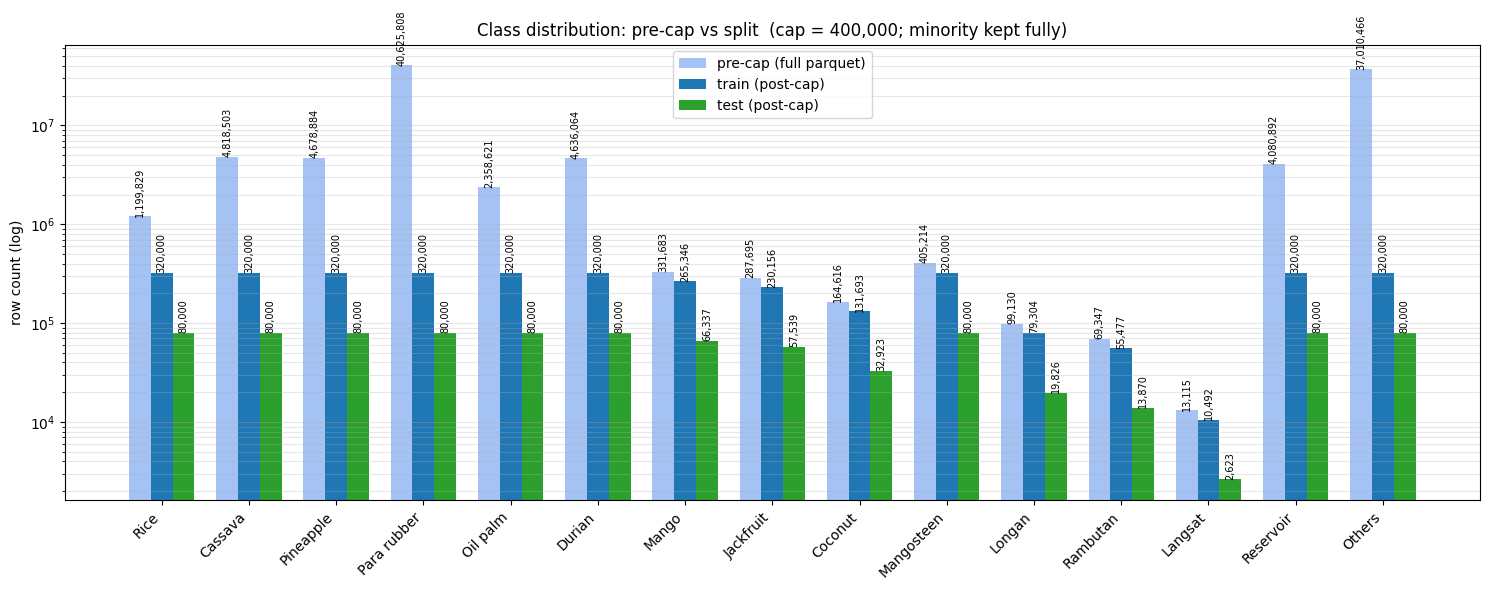

In [2]:
import time, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def class_counts(y):
    cnt = dict.fromkeys(range(N_CLASSES), 0)
    for c, n in zip(*np.unique(y, return_counts=True)):
        cnt[int(c)] = int(n)
    return cnt

df = pd.read_parquet(OUT_PARQ)
print(f'rows: {len(df):,}  NaN cells (features): '
      f'{int(df[FEATURE_COLS].isna().sum().sum()):,}')

n_filled_total = 0
for idx_name in INDEX_NAMES:
    cols = [f'{idx_name} {m}' for m in MONTHS]
    arr = np.array(df[cols], dtype=np.float32)   # explicit copy → writeable
    for i in range(len(cols)):
        others = [j for j in range(len(cols)) if j != i]
        others_data = arr[:, others]
        n_valid    = (~np.isnan(others_data)).sum(axis=1)
        sum_valid  = np.nansum(others_data, axis=1)
        mean_others = np.where(n_valid > 0, sum_valid / np.maximum(n_valid, 1), np.nan)
        mask = np.isnan(arr[:, i])
        n_filled_total += int(mask.sum())
        arr[mask, i] = mean_others[mask]
    df[cols] = arr
print(f'cross-month NaN fills: {n_filled_total:,}')

# Drop only the residual rows where some index is still NaN across ALL months.
before = len(df)
df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f'rows after impute+residual-drop: {before:,} -> {len(df):,}')

# ---- pre-cap counts ----
pre_cap = class_counts(df['label'].to_numpy())

# ---- per-class cap on FULL parquet; minority kept FULLY ----
TOTAL_PER_CLASS_CAP = 400_000
y_arr = df['label'].to_numpy()
rng = np.random.default_rng(42)
keep_parts: List[np.ndarray] = []
for cid in range(N_CLASSES):
    cls_idx = np.flatnonzero(y_arr == cid)
    if len(cls_idx) > TOTAL_PER_CLASS_CAP:
        cls_idx = rng.choice(cls_idx, TOTAL_PER_CLASS_CAP, replace=False)
    keep_parts.append(cls_idx)
keep_idx = np.concatenate(keep_parts)
del keep_parts, y_arr; gc.collect()
rng.shuffle(keep_idx)
df = df.iloc[keep_idx].reset_index(drop=True)
del keep_idx; gc.collect()
print(f'after per-class cap @ {TOTAL_PER_CLASS_CAP:,}: rows = {len(df):,}')

X_all = df[FEATURE_COLS].to_numpy(dtype=np.float32)
y_all = df['label'].to_numpy(dtype=np.int32)
del df; gc.collect()

# ---- stratified 80 / 20 train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all,
)
del X_all, y_all; gc.collect()
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

# ---- per-split class counts ----
train_cnt = class_counts(y_train)
test_cnt  = class_counts(y_test)
counts_df = pd.DataFrame({
    'class':   [CLASSES[c] for c in range(N_CLASSES)],
    'pre_cap': [pre_cap[c]   for c in range(N_CLASSES)],
    'train':   [train_cnt[c] for c in range(N_CLASSES)],
    'test':    [test_cnt[c]  for c in range(N_CLASSES)],
}).set_index('class')
print('\nclass counts (pre-cap = post-impute full parquet; train/test = post-cap stratified 80/20):')
print(counts_df.to_string())

# ---- bar chart of counts (log y) ----
xpos = np.arange(N_CLASSES)
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
series = [
    (counts_df['pre_cap'], -w, 'pre-cap (full parquet)', '#a4c2f4'),
    (counts_df['train'],    0, 'train (post-cap)',       '#1f77b4'),
    (counts_df['test'],     w, 'test (post-cap)',        '#2ca02c'),
]
for vals, off, lbl, color in series:
    ax.bar(xpos + off, vals, w, label=lbl, color=color)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(xpos[i] + off, v, f'{v:,}', rotation=90, va='bottom', ha='center', fontsize=7)
ax.set_yscale('log')
ax.set_xticks(xpos); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('row count (log)')
ax.set_title(f'Class distribution: pre-cap vs split  (cap = {TOTAL_PER_CLASS_CAP:,}; minority kept fully)')
ax.legend()
ax.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout(); plt.show()

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score


# ---- inner train / val carve-out for HPO (test stays untouched) ----
X_in_tr, X_in_va, y_in_tr, y_in_va = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train,
)
print(f'Optuna inner-train: {X_in_tr.shape}   inner-val: {X_in_va.shape}')

N_TRIALS = 8     # bump if RAM/time allow
N_JOBS   = 6     # cap loky workers (Windows forks training data)
CLASS_LABELS = list(range(N_CLASSES))

# Quiet Optuna's per-trial INFO log; we print our own line.
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.Trial) -> float:
    """Sample RF params, fit on inner-train, return inner-val macro-F1.

    Tuning the knobs that matter for minority-class collapse on this larger dataset:
      class_weight       -- 'balanced_subsample' often beats 'balanced' under heavy imbalance.
      min_samples_leaf   -- smaller leaves preserve fine patterns of rare classes (=1 blows RAM here).
      max_features       -- fewer features per split → more decorrelated trees.
      max_depth          -- too shallow underfits the minority.
    """
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 400, step=50),
        'max_depth':         trial.suggest_categorical('max_depth', [None, 25, 30, 35, 40]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 2, 5),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
    }
    clf = RandomForestClassifier(
        **params, bootstrap=True, random_state=42, n_jobs=N_JOBS,
    )
    t0 = time.time()
    clf.fit(X_in_tr, y_in_tr)
    fit_dt = time.time() - t0
    yp  = clf.predict(X_in_va)
    f1m = f1_score(y_in_va, yp, average='macro',    labels=CLASS_LABELS, zero_division=0)
    f1w = f1_score(y_in_va, yp, average='weighted', labels=CLASS_LABELS, zero_division=0)
    acc = accuracy_score(y_in_va, yp)
    kap = cohen_kappa_score(y_in_va, yp)
    print(f'  trial {trial.number + 1:2d}/{N_TRIALS}  macro-F1={f1m:.4f}  '
          f'weighted-F1={f1w:.4f}  acc={acc:.4f}  +{fit_dt:.1f}s  {params}')
    trial.set_user_attr('weighted_f1', f1w)
    trial.set_user_attr('acc', acc)
    trial.set_user_attr('kappa', kap)
    trial.set_user_attr('fit_s', fit_dt)
    del clf, yp; gc.collect()
    return f1m


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='rf_macro_f1',
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True)

# ---- build trials_df (cell 17 references it for the recap table) ----
rows = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    rows.append({
        'trial':       t.number + 1,
        'macro_f1':    t.value,
        'weighted_f1': t.user_attrs.get('weighted_f1'),
        'acc':         t.user_attrs.get('acc'),
        'kappa':       t.user_attrs.get('kappa'),
        'fit_s':       t.user_attrs.get('fit_s'),
        **t.params,
    })
trials_df = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print('\nOptuna trials (sorted by macro-F1, best first):')
print(trials_df.to_string())

del X_in_tr, y_in_tr, X_in_va, y_in_va; gc.collect()

best_params = dict(study.best_params)
print(f'\nbest params (inner-val macro-F1 = {study.best_value:.4f}):')
for k, v in best_params.items():
    print(f'  {k:20s} {v}')

# ---- refit on FULL train with best params ----
print(f'\nfinal fit on full train ({len(X_train):,} rows) with best params ...')
best_rf = RandomForestClassifier(
    **best_params, bootstrap=True, random_state=42, n_jobs=N_JOBS,
)

t0 = time.time()
best_rf.fit(X_train, y_train)
print(f'fit: {time.time() - t0:.1f}s')
del X_train, y_train; gc.collect()

joblib.dump(best_rf, 'random_forest_model.joblib')
print('Model saved → random_forest_model.joblib')


Optuna inner-train: (3104597, 15)   inner-val: (547871, 15)


Best trial: 0. Best value: 0.509156:  12%|█████▌                                      | 1/8 [15:38<1:49:32, 938.93s/it]

  trial  1/8  macro-F1=0.5092  weighted-F1=0.5430  acc=0.5459  +916.2s  {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    cohen_kappa_score, f1_score, classification_report,
)


def eval_split(name: str, Xs: np.ndarray, ys: np.ndarray) -> np.ndarray:
    yp  = best_rf.predict(Xs)
    acc = accuracy_score(ys, yp)
    kap = cohen_kappa_score(ys, yp)
    f1w = f1_score(ys, yp, average='weighted')
    f1m = f1_score(ys, yp, average='macro', labels=list(range(N_CLASSES)), zero_division=0)
    pre = precision_score(ys, yp, average='weighted', zero_division=0)
    rec = recall_score(ys, yp, average='weighted', zero_division=0)
    print(f'\n=== {name} Performance ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'Kappa    : {kap:.4f}')
    print(f'F1       : {f1w:.4f}  (weighted)   {f1m:.4f}  (macro)')
    print(f'Precision: {pre:.4f}  (weighted)')
    print(f'Recall   : {rec:.4f}  (weighted)')
    f1_pc = f1_score(ys, yp, average=None, labels=list(range(N_CLASSES)), zero_division=0)
    print(f'\nper-class F1 ({name}):')
    for cid, fc in enumerate(f1_pc):
        n = int((ys == cid).sum())
        print(f'  {cid:2d}  {CLASSES[cid]:12s}  F1={fc:.4f}   support={n:,}')
    print(f'\nclassification_report ({name}):')
    print(classification_report(
        ys, yp, labels=list(range(N_CLASSES)),
        target_names=CLASSES, digits=3, zero_division=0,
    ))
    del yp
    return f1_pc


f1_test = eval_split('Test', X_test, y_test)
del X_test, y_test; gc.collect()

# ---- per-class F1 bar chart ----
xpos = np.arange(N_CLASSES)
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(xpos, f1_test, 0.6, label='test', color='#2ca02c')
for i, ft in enumerate(f1_test):
    ax.text(xpos[i], ft, f'{ft:.2f}', va='bottom', ha='center', fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('F1')
ax.set_title('per-class F1 — test  (best HPO model)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ---- HPO trials vs test summary ----
print('\nHPO trials (recap):')
print(trials_df[['trial', 'macro_f1', 'weighted_f1', 'acc',
                 'n_estimators', 'max_depth', 'min_samples_split',
                 'min_samples_leaf', 'max_features', 'class_weight']].to_string(index=False))

# ---- feature importance ----
imp = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('\nfeature importance (top → bottom):')
print(imp.to_string())
